In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [9]:
df = pd.read_csv('/kaggle/input/datasets/jitendar7817/tweet-analysis/Tweets (1).csv')

print(df.head())
print(df.columns)

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [11]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [13]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [14]:
model = LinearSVC()
model.fit(X_train_vec, y_train)

LinearSVC()

In [15]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6734582499545206

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.62      0.64      1556
           1       0.63      0.68      0.65      2224
           2       0.74      0.72      0.73      1717

    accuracy                           0.67      5497
   macro avg       0.68      0.67      0.68      5497
weighted avg       0.68      0.67      0.67      5497



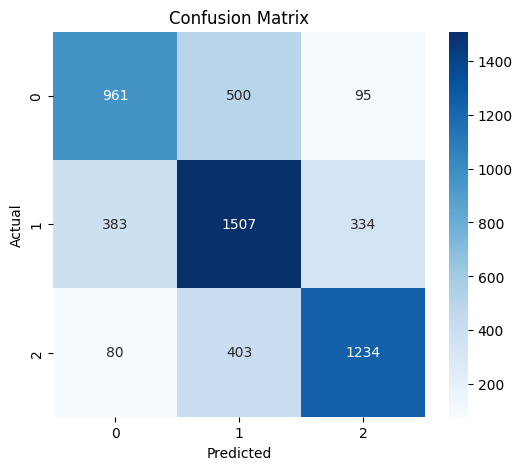

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

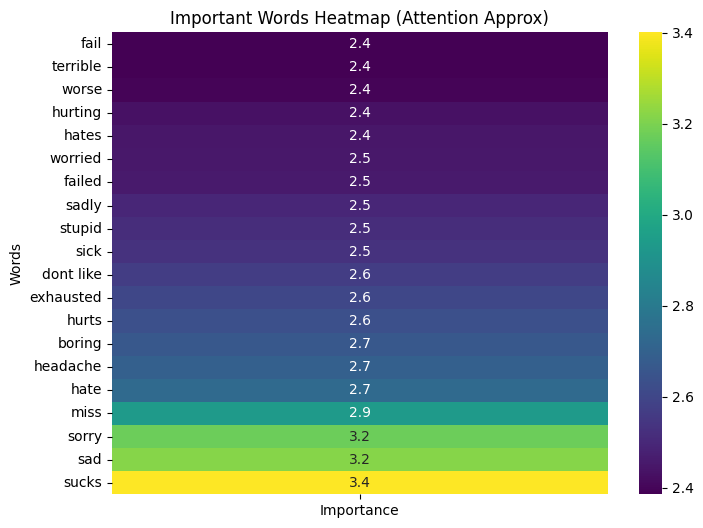

In [17]:
feature_names = vectorizer.get_feature_names_out()
weights = model.coef_[0]

top_n = 20
top_indices = np.argsort(weights)[-top_n:]

top_features = [feature_names[i] for i in top_indices]
top_weights = weights[top_indices]

heatmap_df = pd.DataFrame({
    "Words": top_features,
    "Importance": top_weights
})

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_df.set_index("Words"),
    annot=True,
    cmap="viridis"
)

plt.title("Important Words Heatmap (Attention Approx)")
plt.show()

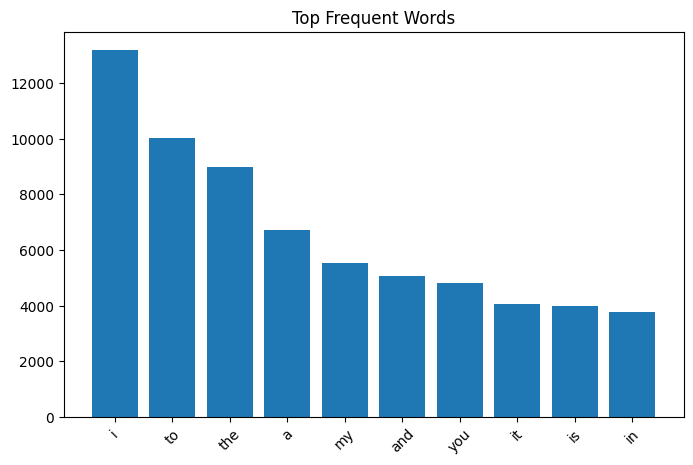

In [18]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(10)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(8,5))
plt.bar(words, counts)
plt.title("Top Frequent Words")
plt.xticks(rotation=45)
plt.show()